In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from visions import typesets

import sys
sys.path.append("../HICode")
from label_generation import generate_labels, save_generation_output
from label_clustering import cluster_labels_gpt, make_clustering_prompt
from map_clustering import *

# Results Page

## Step 1: Run Pipeline at Main Page
**Input Format: Tabular data  ===> Output Format: JSON data**

### Upload Data / Connect to database
Requirement: For the user input, we require the dataset to be in a csv format with at least two columns: `text_id` and `text`. The `text_id` column should contain unique identifiers for each review, while the `text` column should contain the actual review text. The dataset can also include additional columns as metadata.

**Now we assume the input data also contains other metadata columns.**


In [2]:
review_df = pd.read_csv("./doctor_review_sample1000.csv")
review_df.head()

,text,PhyID,text_id,platform,NPI,FirstName,LastName,Gender,Credential,Specialty,...,num_reviews,DocName,PhysicianType,parsed_review_count,population,population_density,median_household_income,county,city,state
0,My mother in law was diagnosed with colon canc...,100711211,3103437,Vitals,1629071337,AUGUSTO,MARTINEZ,M,MD,Colon & Rectal Surgery Physician,...,15.0,Dr. Augusto Martinez,Specialty,15,18175.0,2739.0,40360.0,Montgomery County,Dayton,OH
1,I am very satisfied.,100823913,3606054,Vitals,1720044886,STANLEY,GWOCK,M,MD,Family Medicine Physician,...,8.0,Dr. Stanley Gwock,Primary Care,8,21586.0,1462.0,53483.0,Leon County,Tallahassee,FL
2,I needed an ENT and since i dont require a pri...,100797376,3483408,Vitals,1699878736,LARRY,SHEMEN,M,MD,Otolaryngology Physician,...,91.0,Dr. Larry Shemen,Specialty,91,43631.0,112711.0,107907.0,New York County,New York,NY
3,I came into Winthrop Emergency Room after a fa...,100538536,2349846,Vitals,1477516862,OMID,BARZIDEH,M,MD,Orthopaedic Surgery Physician,...,103.0,Dr. Omid Barzideh,Specialty,103,27273.0,3841.0,135370.0,Nassau County,Garden City,NY
4,The staff at PSW work cohesively to provide a ...,100685460,2991163,Yelp,1609020981,VADIM,PISARENKO,M,MD,Surgery Physician,...,36.0,Dr. Vadim Pisarenko,Specialty,36,12280.0,3209.0,99888.0,Westchester County,Harrison,NY


In [ ]:
review_df["segment_id"] = review_df["text_id"].apply(lambda x: str(x)+"_0")
hicode_input = dict(zip(review_df["segment_id"], review_df["text"]))
hicode_input.keys()

dict_keys(['3103437_0', '3606054_0', '3483408_0', '2349846_0', '2991163_0', '2783355_0', '1570028_0', '2138802_0', '4564855_0', '3168966_0', '1396815_0', '4930959_0', '1825008_0', '4677636_0', '2056045_0', '2501833_0', '3873814_0', '1998834_0', '371307_0', '3874385_0', '235083_0', '3552757_0', '2908812_0', '3234016_0', '926521_0', '3887307_0', '2965041_0', '3730238_0', '1978407_0', '2031424_0', '3630352_0', '4556283_0', '2063824_0', '965071_0', '2026858_0', '4066860_0', '4654022_0', '1331997_0', '3744912_0', '4545884_0', '3693257_0', '3807236_0', '303555_0', '3461218_0', '4563712_0', '4107380_0', '2126391_0', '4061544_0', '4048625_0', '578318_0', '1353310_0', '4337475_0', '4189884_0', '4071924_0', '1560937_0', '144683_0', '1054528_0', '2438657_0', '4950668_0', '2672268_0', '4054924_0', '1350163_0', '24560_0', '1423290_0', '728924_0', '2949652_0', '1331519_0', '1059520_0', '3969323_0', '3642805_0', '4837279_0', '1674233_0', '2246953_0', '193931_0', '1475278_0', '2733857_0', '27278_0', '

In [ ]:
# What analysis do you want to explore?
coding_goal = "How did the patients get referred to the current provider?"

background = """
The online physician review dataset contains millions of public patient reviews 
about physicians from different healthcare providers. Public health researchers are 
interested in understanding exploratory research questions about patient experiences 
from these reviews.
"""

# Define the system prompt for label generation

system_prompt = f"""
{background}

We are using the queries to this bot to conduct INDUCTIVE Coding. The labeling aims to {coding_goal}

Instruction:
- Label the input only when it is HIGHLY RELEVANT and USEFUL for {coding_goal}.
- Then, define the phrase of the label. The label description should be observational, concise and clear.
- ONLY output the label and DO NOT output any explanation.

Format:
- Define the label using the format \"LABEL: [The phrase of the label]\". 
- If there are multiple labels, each label is a new line. 
- If the input is irrelevant, use \"LABEL: [Irrelevant]\". 
"""

# Configuration 
config = {
# Generation Model 
"model_name": "gpt-4o-mini",

# Generation
"generation_output_dir": "./results/generation", # Change Me to your desired output directory

# CLustering Model
"cluster_model_name": "gpt-4o-mini",
"cluster_output_dir": "./results/clustering" # Change Me to your desired output directory
}

In [7]:
gen_result = generate_labels(hicode_input, 
                             system_prompt, 
                             config)
gen_result_id = save_generation_output(gen_result, 
                                       config["generation_output_dir"])

100%|██████████| 1000/1000 [12:59<00:00,  1.28it/s] 

Saving generation output to ./results/generation/generation_e9858dba-7a3a-11f1-b6c9-b2784844b6f9.json


In [8]:
cluster_prompt = make_clustering_prompt(goal=coding_goal)
cluster_result = cluster_labels_gpt(gen_result, cluster_prompt, config, gen_result_id=gen_result_id)

========Run gpt-4o-mini Clustering=========
Number of batches: 2


100%|██████████| 2/2 [00:17<00:00,  8.81s/it]


Saved iteration 0 clustering result to ./results/clustering/clustering_e9858dba-7a3a-11f1-b6c9-b2784844b6f9/cluster_iter_0.json
Number of batches: 1


100%|██████████| 1/1 [00:02<00:00,  2.52s/it]

Saved iteration 1 clustering result to ./results/clustering/clustering_e9858dba-7a3a-11f1-b6c9-b2784844b6f9/cluster_iter_1.json


Number of labels: 84
Iteration 1: 84 labels left


## Step 2: Analyze Metadata Types


In [4]:
# StandardSet is the basic builtin typeset
typeset = typesets.CompleteSet()
# Infer the types of each column in the dataframe
review_df =typeset.cast_to_inferred(review_df)

### 2.1 Potential Categorical Columns
We can identify potential categorical columns by checking the number of unique values in each column. Columns with a relatively small number of unique values (e.g., less than 10) are likely to be categorical. 


In [5]:
cat_columns = review_df.nunique()[review_df.nunique() <= 10].sort_values(ascending=True).index.tolist()
cat_columns

['Gender', 'PhysicianType', 'platform']

### 2.2 Potential Continuous Columns
Continuous columns are typically numeric and can take on a wide range of values. We can identify potential continuous columns by checking the data type of each column and looking for numeric types (e.g., int, float). Additionally, we can check the number of unique values in each column; continuous columns often have a large number of unique values (e.g., more than 10).

In [27]:
import pandas as pd

def get_continuous_columns(df, unique_ratio = 0.9, max_unique=10):
    cont_columns = []
    for col in df.select_dtypes(include="number").columns:
        name = col.lower()
        # Skip obvious IDs
        if any(x in name for x in ["id", "uuid", "index", "idx"]):
            continue
        # Skip almost unique integer columns
        if (
            pd.api.types.is_integer_dtype(df[col])
            and df[col].nunique() / len(df) > unique_ratio
        ):
            continue
        # Skip categorical variables
        if df[col].nunique() <= max_unique:
            continue

        cont_columns.append(col)
    return cont_columns


cont_columns = get_continuous_columns(review_df)

## Step 3: Visualize Metadata Distribution

Construct a new dataframe that contains the `text_id` and `theme`. Use this dataframe to merge with the original review dataframe to include the metadata columns. Then, we can visualize the distribution of themes across different metadata categories.

In [13]:
gen_result_id = "e9858dba-7a3a-11f1-b6c9-b2784844b6f9"
generated_label_map = create_mapping(f"./results/clustering/clustering_{gen_result_id}/")
generation_file = f"./results/generation/generation_{gen_result_id}.json"
doc_labeled_by_theme = map_clusters(generation_file, generated_label_map)
# Build a (text_id, theme) table, one row per theme mentioned in a review.
# doc_labeled_by_theme is keyed by text_id (generate_labels strips the "_0"
# segment suffix), so join on text_id rather than segment_id.
rows = []
for doc_id, doc_data in doc_labeled_by_theme.items():
    doc_themes = set()
    for ann in doc_data["LLM_Annotation"]:
        doc_themes.update(ann["label"])
    for theme in doc_themes:
        rows.append({"text_id": int(doc_id), "theme": theme})

theme_df = pd.DataFrame(rows)
theme_df.head()

Number of labels: 84
Iteration 1: 84 labels left


,text_id,theme
0,3103437,recommendations
1,3483408,self-referral
2,1396815,recommendations
3,2908812,dissatisfaction
4,2438657,care continuity


### 3.1 Theme prevalence by categorical metadata columns

<Figure size 1000x600 with 0 Axes>

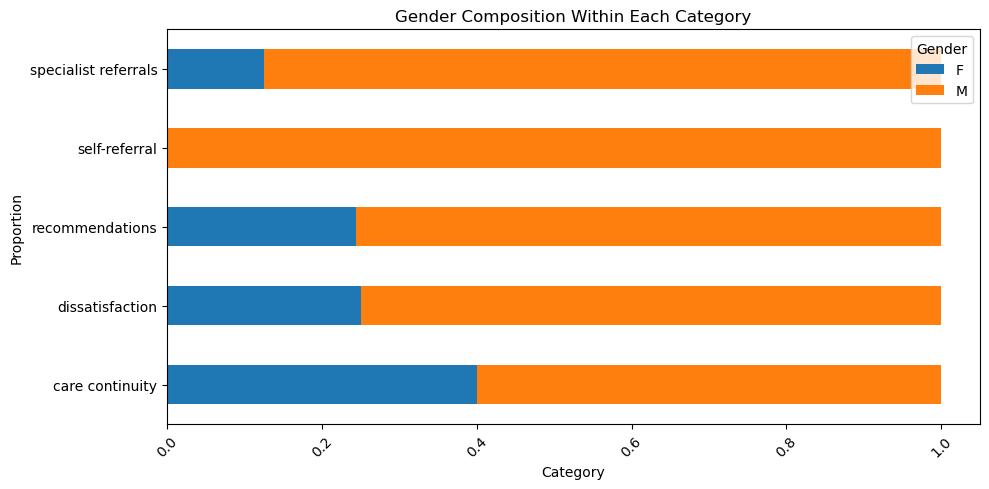

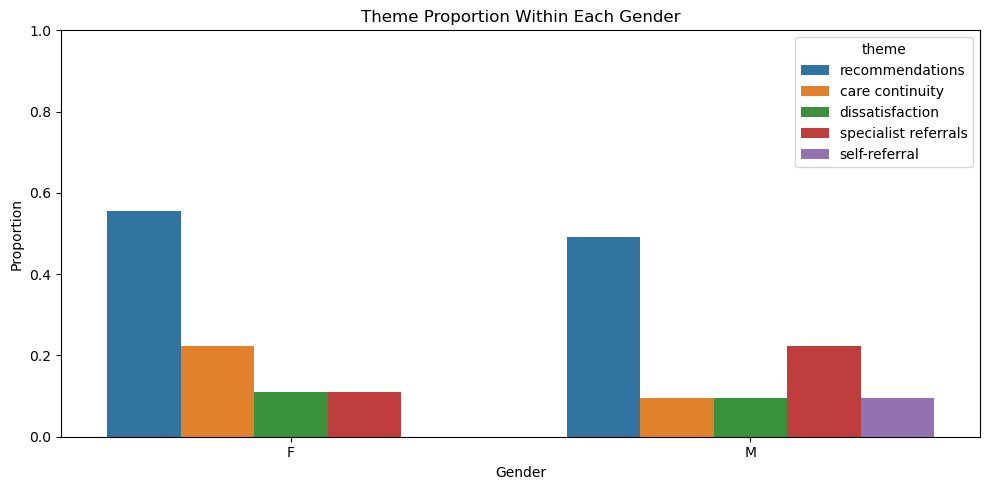

<Figure size 1000x600 with 0 Axes>

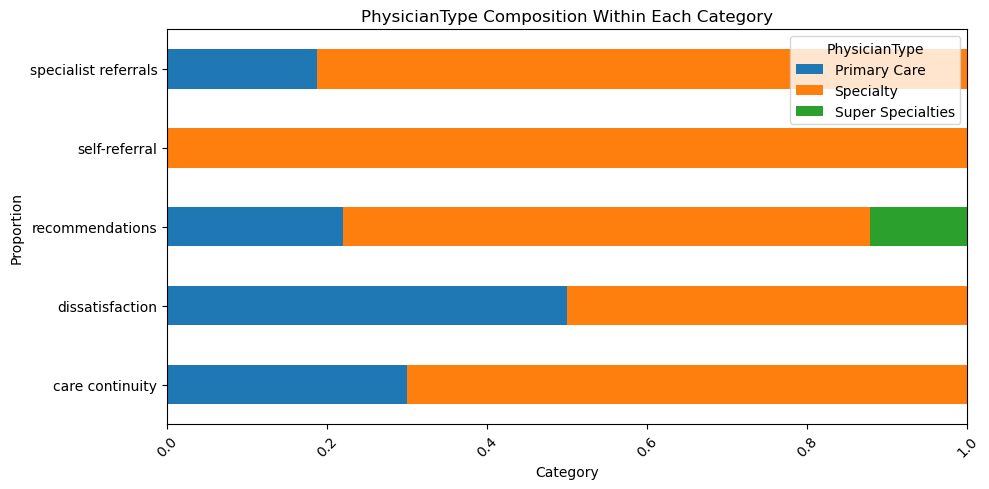

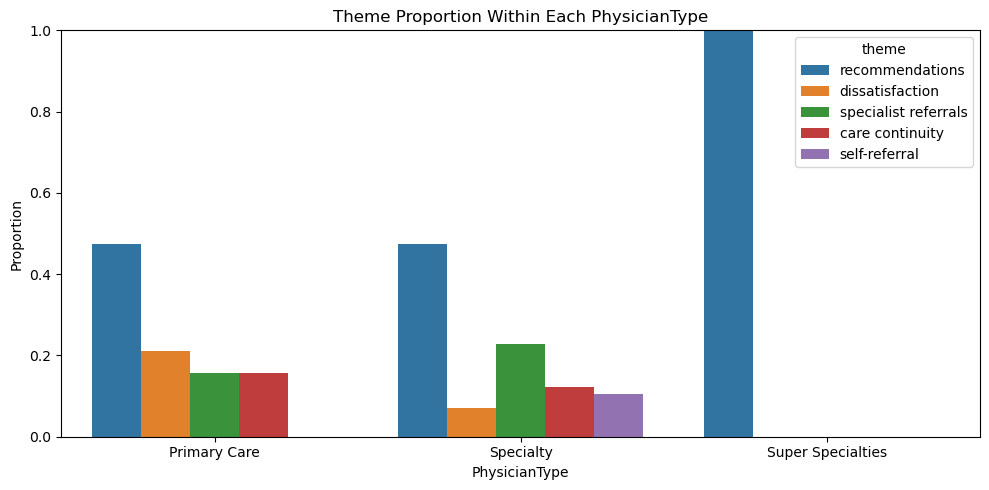

<Figure size 1000x600 with 0 Axes>

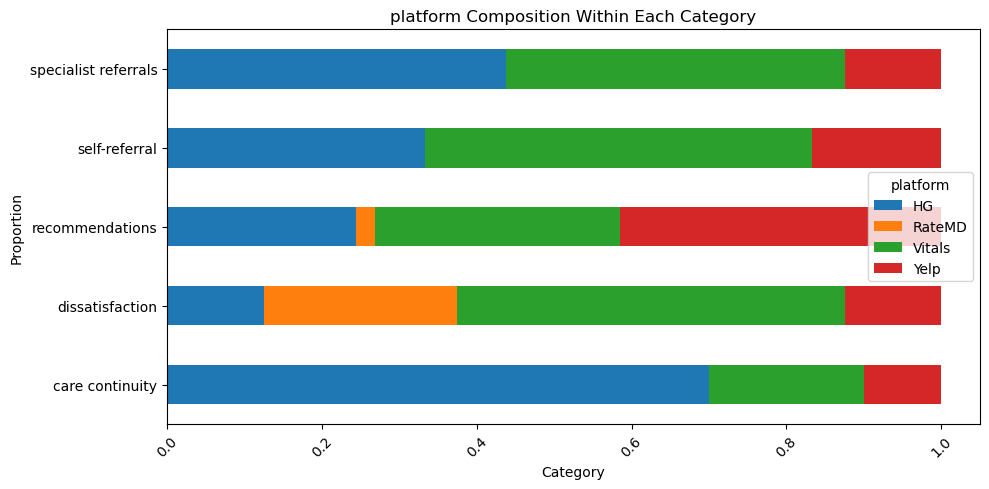

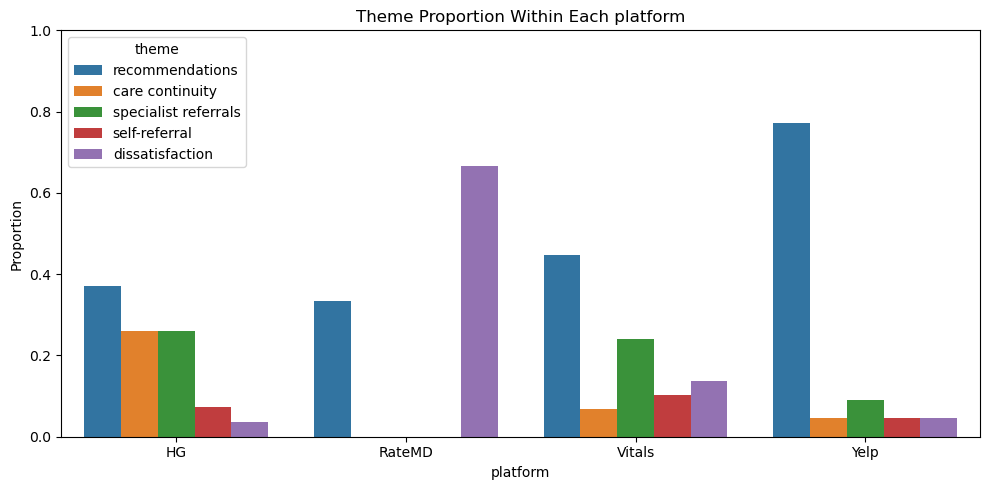

In [14]:
for cat_var in cat_columns:
    plt.figure(figsize=(10, 6))
    plot_df = theme_df.merge(review_df[["text_id", cat_var]], on="text_id", how="left")
    tab = pd.crosstab(
        plot_df["theme"],
        plot_df[cat_var],
        normalize="index"
    )

    tab.plot(
        kind="barh",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"{cat_var} Composition Within Each Category")
    plt.xlabel("Category")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend(title=cat_var)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    prop = (
        plot_df.groupby(cat_var)["theme"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=prop,
        x=cat_var,
        y="proportion",
        hue="theme"
    )

    plt.title(f"Theme Proportion Within Each {cat_var}")
    plt.xlabel(cat_var)
    plt.ylabel("Proportion")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

### 3.2 Theme prevalence by continuous metadata columns

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


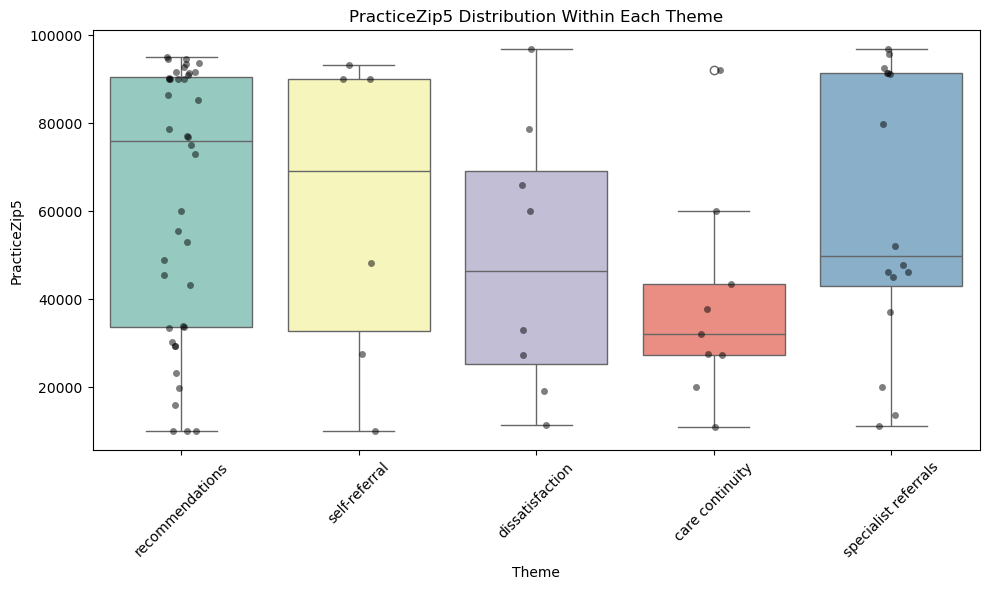

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


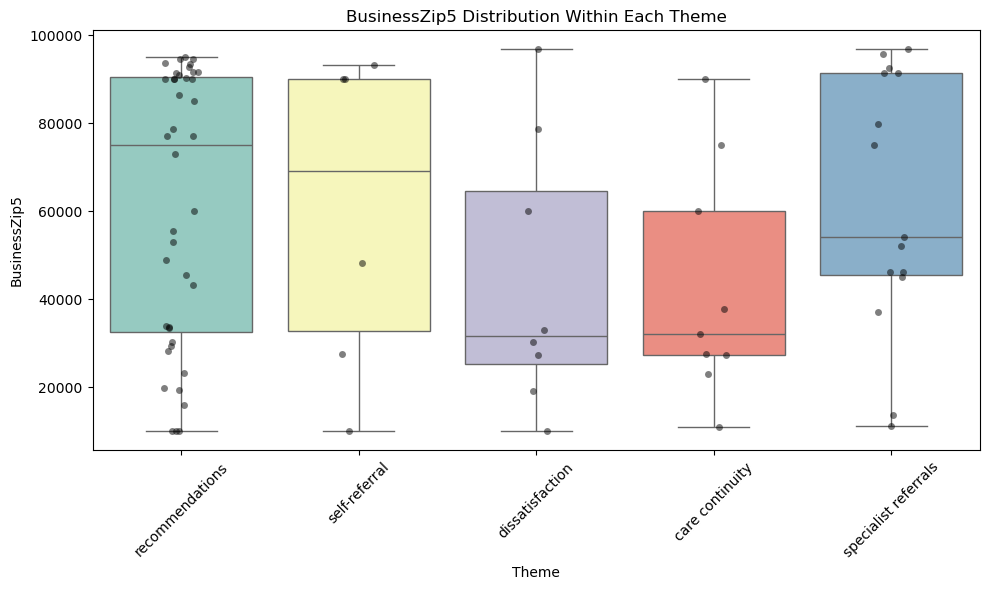

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


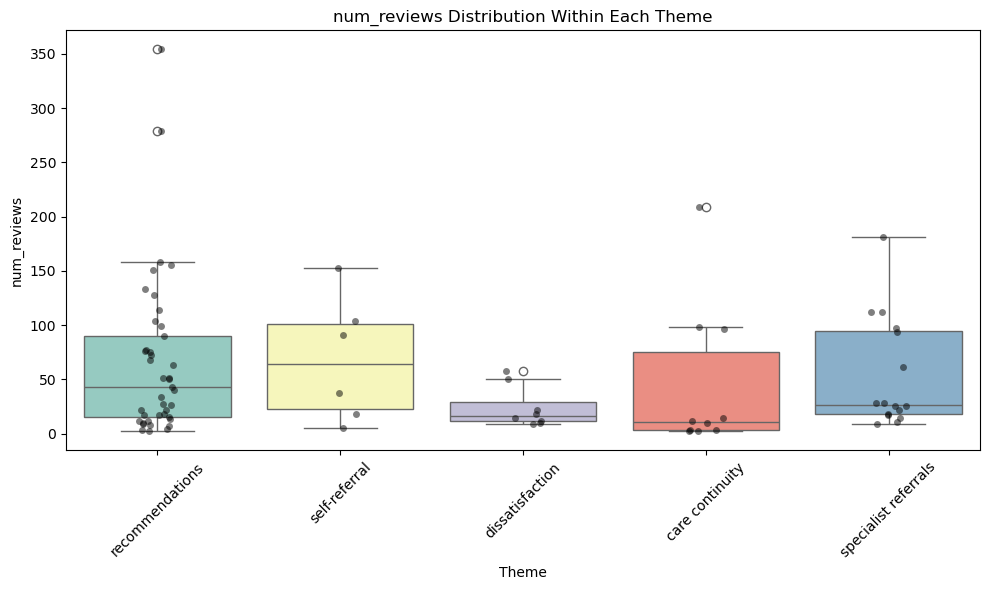

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


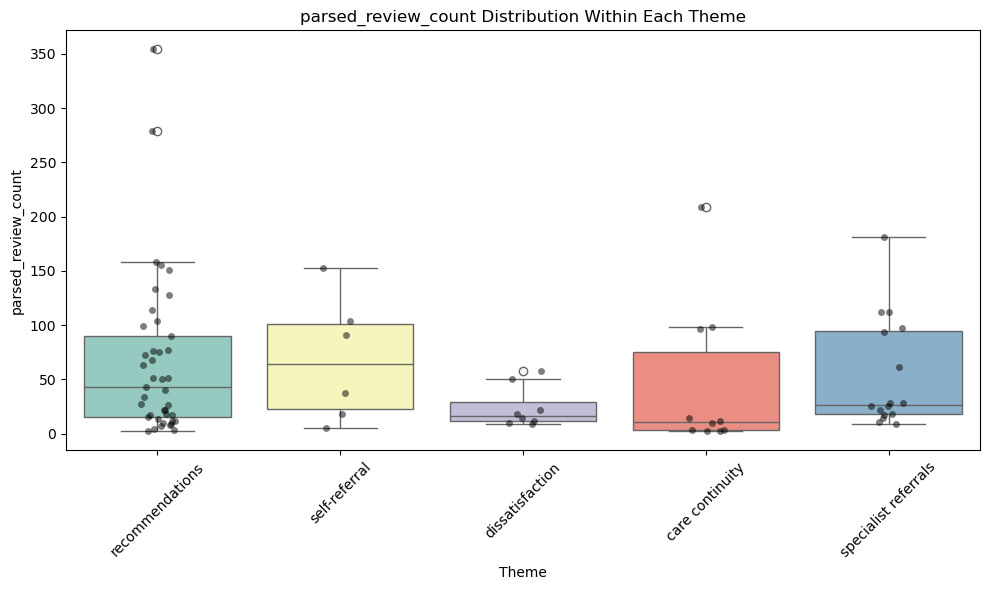

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


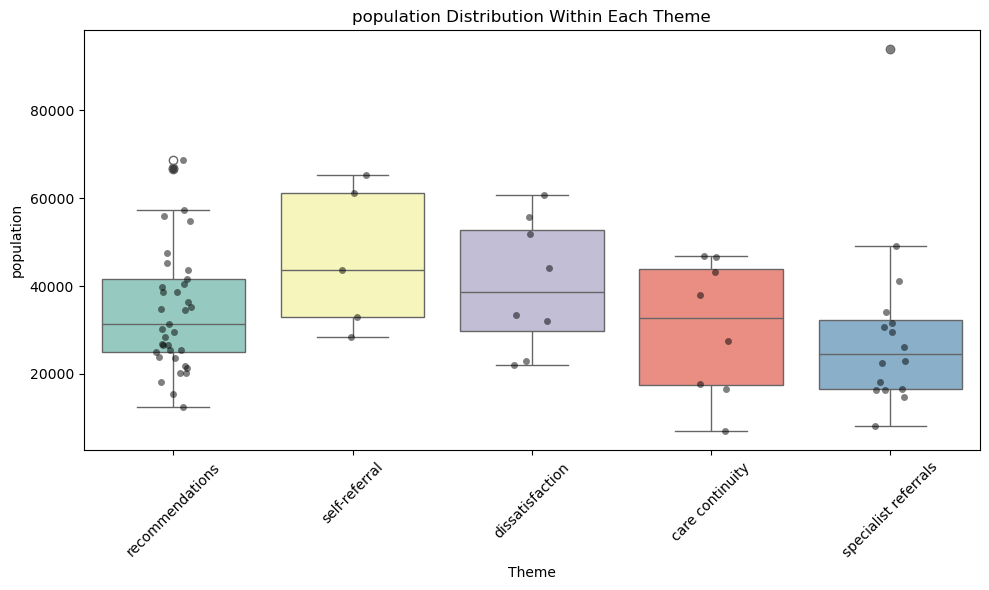

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


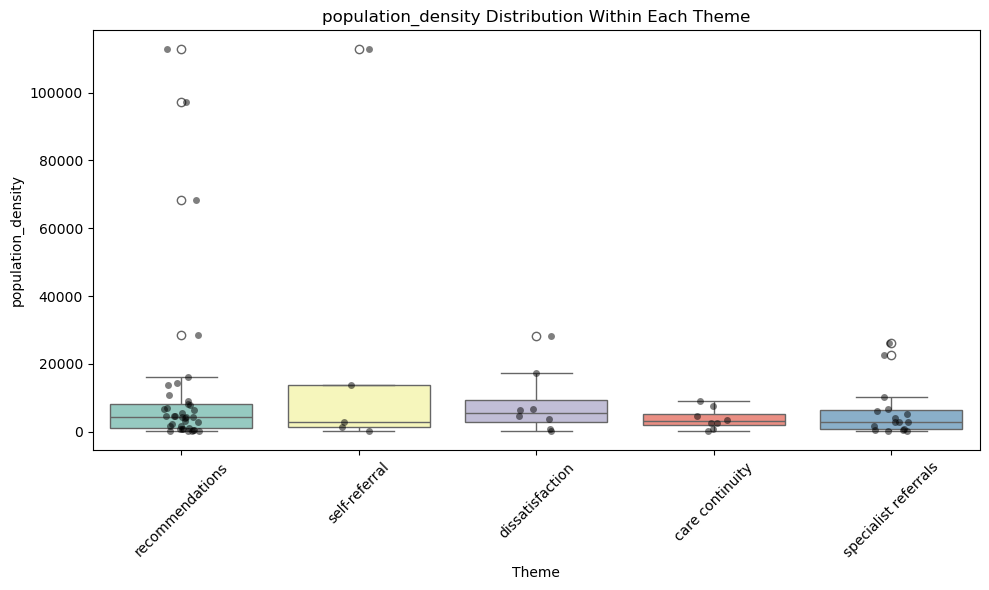

/var/folders/td/ykvwvd8j2nv3lfd6tx6t5k880000gn/T/ipykernel_9630/2682356135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")


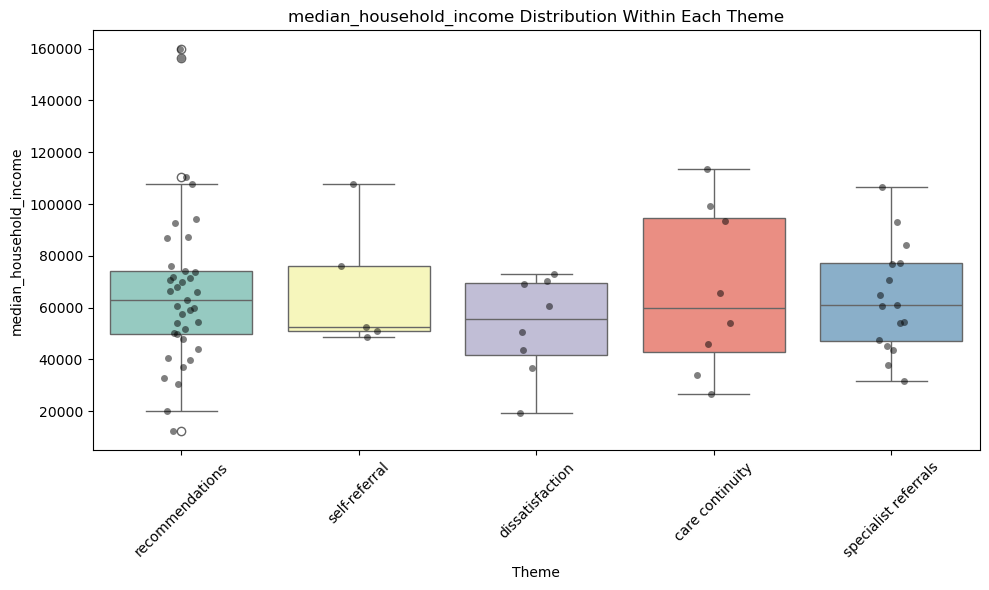

In [28]:
for cont_var in cont_columns:
    plt.figure(figsize=(10, 6))
    plot_df = theme_df.merge(review_df[["text_id", cont_var]], on="text_id", how="left")
    sns.boxplot(data=plot_df, x="theme", y=cont_var, palette="Set3", orient="v")
    sns.stripplot(data=plot_df, x="theme", y=cont_var, color="black", alpha=0.5, jitter=True)
    plt.title(f"{cont_var} Distribution Within Each Theme")
    plt.xlabel("Theme")
    plt.ylabel(cont_var)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:

### Theme Prevalence by State

# We map each review's generated labels to their final theme (using `generated_label_map`), then join with the `state` metadata column from `review_df` to visualize how theme prevalence varies geographically.
# theme_df = theme_df.merge(review_df, on="text_id", how="left")
# theme_df = theme_df.dropna(subset=["state"])
# theme_df.head()


# import plotly.graph_objects as go

# state_theme_counts = theme_df.groupby(["state", "theme"]).size().reset_index(name="count")

# all_states = sorted(theme_df["state"].unique())
# themes = sorted(theme_df["theme"].unique())

# fig = go.Figure()
# for i, theme in enumerate(themes):
#     counts_by_state = (
#         state_theme_counts[state_theme_counts["theme"] == theme]
#         .set_index("state")["count"]
#         .reindex(all_states, fill_value=0)
#     )
#     fig.add_trace(
#         go.Choropleth(
#             locations=all_states,
#             z=counts_by_state.values,
#             locationmode="USA-states",
#             colorscale="Blues",
#             colorbar_title="# Reviews",
#             visible=(i == 0),
#             name=theme,
#         )
#     )

# buttons = [
#     dict(
#         label=theme,
#         method="update",
#         args=[
#             {"visible": [t == theme for t in themes]},
#             {"title": f"Theme Prevalence by State: {theme}"},
#         ],
#     )
#     for theme in themes
# ]

# fig.update_layout(
#     title=f"Theme Prevalence by State: {themes[0]}",
#     geo_scope="usa",
#     updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1)],
# )
# fig.show()